In [6]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [7]:
data=pd.read_csv("food_delivery_time_dataset_10000.csv")
data

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,1,9.99,Clear,Medium,Morning,Scooter,14,1.6,57.6
1,2,23.82,Clear,Low,Evening,Bike,14,9.6,82.1
2,3,18.57,Clear,Medium,Afternoon,Scooter,11,2.2,97.5
3,4,15.37,Rainy,Medium,Morning,Bike,24,1.9,110.1
4,5,4.74,Clear,Medium,Afternoon,Scooter,18,3.9,34.2
...,...,...,...,...,...,...,...,...,...
9995,9996,21.58,Foggy,High,Morning,Bike,24,0.9,192.5
9996,9997,22.54,Clear,Medium,Night,Bike,20,4.6,119.9
9997,9998,23.72,Clear,Low,Afternoon,Bike,11,8.3,67.5
9998,9999,10.54,Clear,Medium,Morning,Bike,31,4.4,76.4


### EDA


In [8]:
data.shape

(10000, 9)

In [9]:
data.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time             0
dtype: int64

### Outliers 

In [10]:
num_cols = [
    'Distance_km',
    'Preparation_Time_min',
    'Courier_Experience_yrs',
    'Delivery_Time'
]

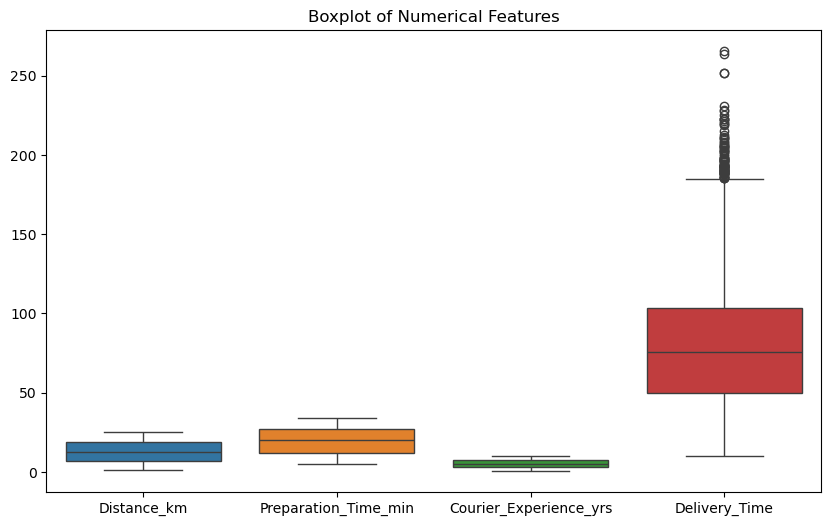

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data[num_cols])
plt.title("Boxplot of Numerical Features")
plt.show()

### Doing some Basic plots Like 

C:\Users\nisha\AppData\Local\Temp\ipykernel_14060\1790605525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Traffic_Level', y='Delivery_Time', data=data, errorbar=None,palette=colors)


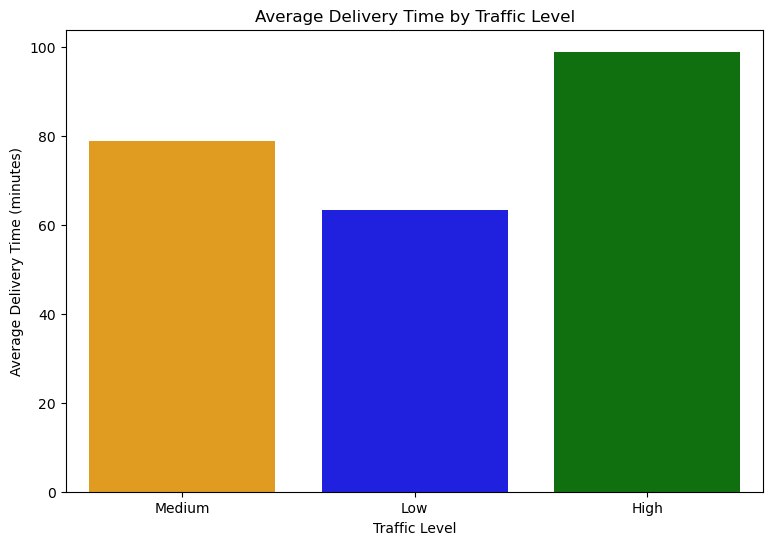

In [12]:
plt.figure(figsize=(9, 6))
colors = ["orange", "blue", "green"]
sns.barplot(x='Traffic_Level', y='Delivery_Time', data=data, errorbar=None,palette=colors)
plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")
plt.show()

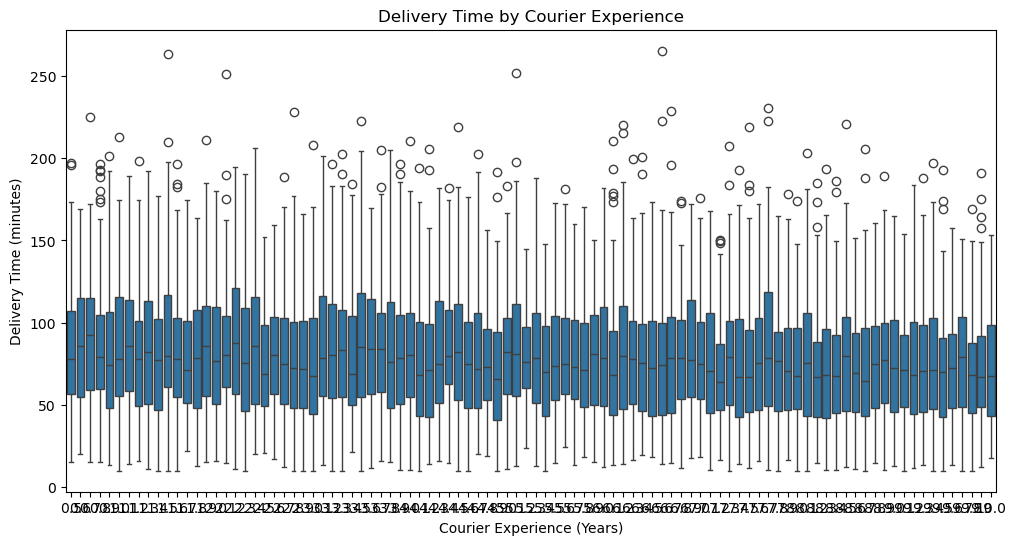

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Courier_Experience_yrs', y='Delivery_Time',data=data)
plt.title("Delivery Time by Courier Experience")
plt.xlabel("Courier Experience (Years)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

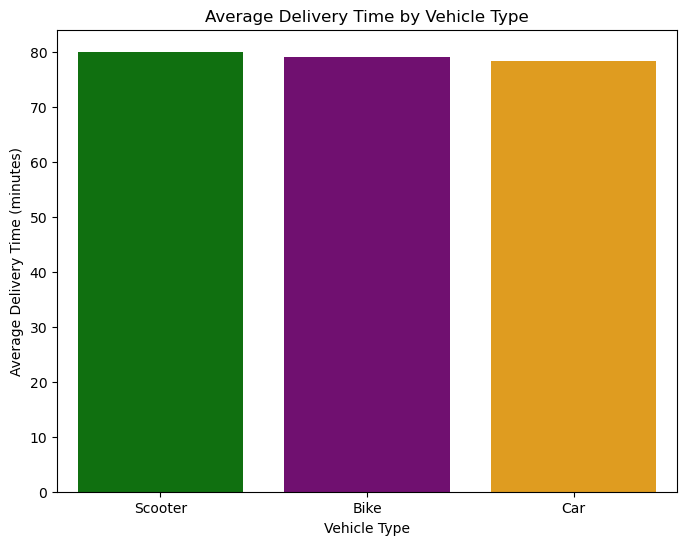

In [14]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Vehicle_Type', y='Delivery_Time', data=data, errorbar=None, hue='Vehicle_Type',palette = {'Scooter': "green", 'Bike': "purple", 'Car': 'orange'})
plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.show()

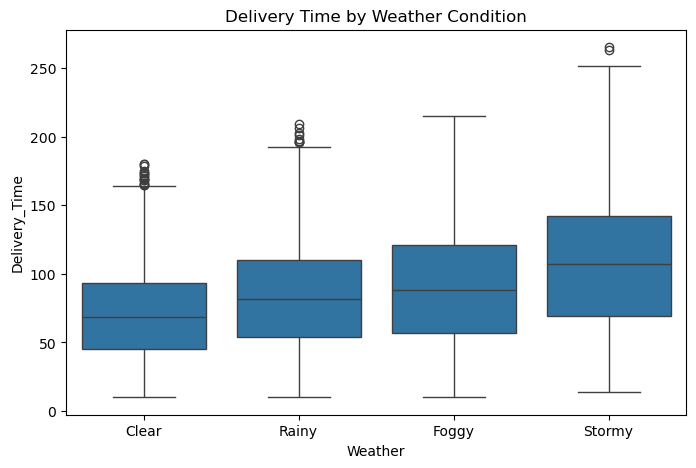

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Weather',
    y='Delivery_Time',
    data=data
)
plt.title("Delivery Time by Weather Condition")
plt.show()


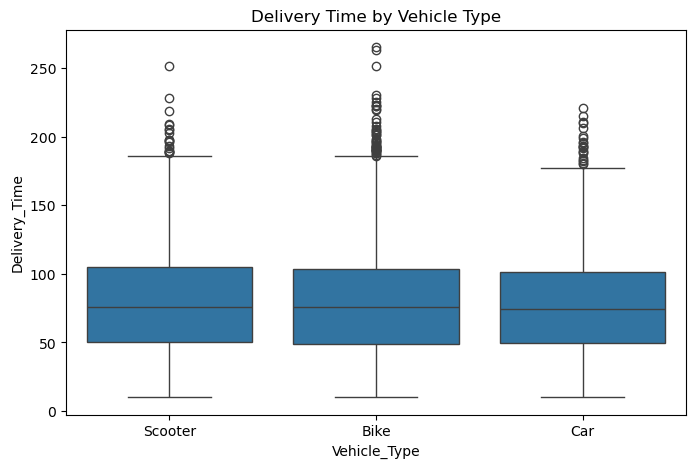

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Vehicle_Type',
    y='Delivery_Time',
    data=data
)
plt.title("Delivery Time by Vehicle Type")
plt.show()

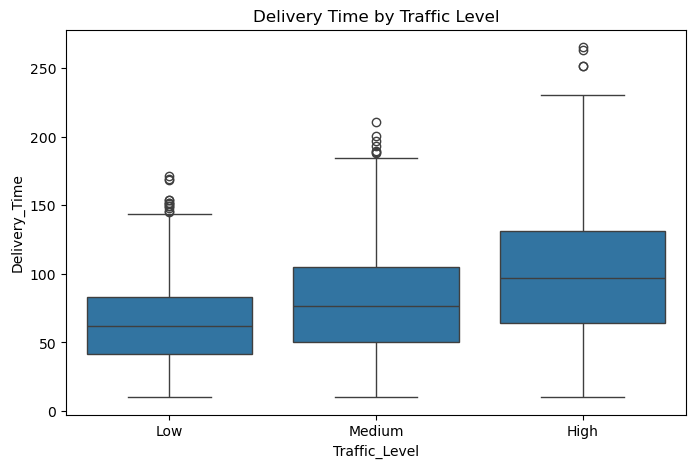

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Traffic_Level',
    y='Delivery_Time',
    data=data,
    order=['Low','Medium','High']
)
plt.title("Delivery Time by Traffic Level")
plt.show()

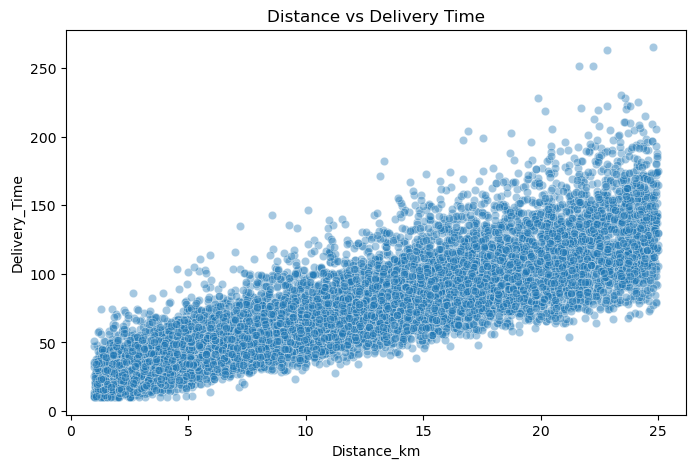

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Distance_km',
    y='Delivery_Time',
    data=data,
    alpha=0.4
)
plt.title("Distance vs Delivery Time")
plt.show()


### Feature Engeering

In [19]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

### Converting Cat into Num

In [20]:
data.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time'],
      dtype='object')

In [21]:
cat_cols=['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time']

In [22]:
for col in cat_cols:
    if data[col].dtype=="object":
        data[col]=LabelEncoder().fit_transform(data[col].astype(str))

In [23]:
data

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,1,9.99,0,2,2,2,14,1.6,57.6
1,2,23.82,0,1,1,0,14,9.6,82.1
2,3,18.57,0,2,0,2,11,2.2,97.5
3,4,15.37,2,2,2,0,24,1.9,110.1
4,5,4.74,0,2,0,2,18,3.9,34.2
...,...,...,...,...,...,...,...,...,...
9995,9996,21.58,1,0,2,0,24,0.9,192.5
9996,9997,22.54,0,2,3,0,20,4.6,119.9
9997,9998,23.72,0,1,0,0,11,8.3,67.5
9998,9999,10.54,0,2,2,0,31,4.4,76.4


In [24]:
data

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,1,9.99,0,2,2,2,14,1.6,57.6
1,2,23.82,0,1,1,0,14,9.6,82.1
2,3,18.57,0,2,0,2,11,2.2,97.5
3,4,15.37,2,2,2,0,24,1.9,110.1
4,5,4.74,0,2,0,2,18,3.9,34.2
...,...,...,...,...,...,...,...,...,...
9995,9996,21.58,1,0,2,0,24,0.9,192.5
9996,9997,22.54,0,2,3,0,20,4.6,119.9
9997,9998,23.72,0,1,0,0,11,8.3,67.5
9998,9999,10.54,0,2,2,0,31,4.4,76.4


In [25]:
x=data.drop(["Delivery_Time"],axis=1)
y=data["Delivery_Time"]
x,y

(      Order_ID  Distance_km  Weather  Traffic_Level  Time_of_Day  \
 0            1         9.99        0              2            2   
 1            2        23.82        0              1            1   
 2            3        18.57        0              2            0   
 3            4        15.37        2              2            2   
 4            5         4.74        0              2            0   
 ...        ...          ...      ...            ...          ...   
 9995      9996        21.58        1              0            2   
 9996      9997        22.54        0              2            3   
 9997      9998        23.72        0              1            0   
 9998      9999        10.54        0              2            2   
 9999     10000         6.21        0              1            2   
 
       Vehicle_Type  Preparation_Time_min  Courier_Experience_yrs  
 0                2                    14                     1.6  
 1                0               

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((8000, 8), (2000, 8), (8000,), (2000,))

### Making the linear model

In [27]:
model=LinearRegression()
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
yhat_train=model.predict(x_train)
yhat_train

array([ 33.12458043, 111.17186244, 136.22667051, ...,  25.18870524,
        79.76808195, 107.94538709])

In [30]:
print(mean_absolute_error(y_train,yhat_train))

12.464789027141203


In [31]:
print(r2_score(y_train,yhat_train))

0.8210218022698135


In [32]:
yhat_test=model.predict(x_test)
yhat_test

array([ 85.88944604,   7.71785063,  27.94712087, ...,  73.49989475,
        63.14460299, 139.30214641])

In [33]:
print(mean_absolute_error(y_test,yhat_test))
print(r2_score(y_test,yhat_test))

12.202474713327854
0.8234348371702679


### Moving to Non-linear model 

In [34]:
from sklearn.ensemble import RandomForestRegressor

In [35]:
forest=RandomForestRegressor(n_estimators=300,max_depth=12,random_state=42)
forest

,n_estimators,300
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
forest.fit(x_train,y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
forest_train=forest.predict(x_train)
forest_train

array([ 34.3185729 , 114.90289835, 174.4658817 , ...,  34.82974183,
        83.69402996, 134.39919814])

In [38]:
print(mean_absolute_error(y_train,forest_train))
print(r2_score(y_train,forest_train))

2.4209097617933506
0.9937433714160676


In [39]:
forest.fit(x_test,y_test)

,n_estimators,300
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
forest_test=forest.predict(x_test)
forest_test

array([ 75.83342649,  27.43425518,  26.30549704, ...,  89.9269746 ,
        46.51413757, 101.07651307])

In [41]:
print(mean_absolute_error(y_test,forest_test))
print(r2_score(y_test,forest_test))

2.2482101343041547
0.9943273159247967


### now we are doing the pipeline

In [42]:
categorical = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
numeric = ['Distance_km','Preparation_Time_min','Courier_Experience_yrs']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', 'passthrough', numeric)
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor())
])

In [43]:
pipeline.fit(x_train,y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
pipeline_train=pipeline.predict(x_train)
pipeline_train

array([ 35.175, 116.375, 174.408, ...,  36.422,  83.817, 136.672])

In [45]:
print(mean_absolute_error(y_train,pipeline_train))
print(r2_score(y_train,pipeline_train))

1.7970437499999994
0.9964009017189288


In [46]:
pipeline.fit(x_test,y_test)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
pipeline_test=pipeline.predict(x_test)
pipeline_test

array([ 75.533,  27.486,  27.01 , ...,  90.334,  46.617, 101.409])

In [48]:
print(mean_absolute_error(y_test,pipeline_test))
print(r2_score(y_test,pipeline_test))

2.0836435000000018
0.994975975208842


In [49]:
import pickle

In [50]:
pickle.dump(pipeline, open("swiggy.pkl","wb"))
